In [1]:
import sys
print(sys.executable)

c:\Users\suzan\OneDrive\Documents\Work Projects\Generating_Questions\.venv311\Scripts\python.exe


In [2]:
from bertopic import BERTopic
import pandas as pd
from umap import UMAP
from hdbscan import HDBSCAN

c:\Users\suzan\OneDrive\Documents\Work Projects\Generating_Questions\.venv311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
with open("questions.txt", "r", encoding="utf-8") as f:
    uncleaned_sentences = f.read().splitlines()

    seen = set()
    sentences = []
    for line in uncleaned_sentences:
        if line not in seen:
            seen.add(line)
            sentences.append(line)

len(sentences)

826

In [4]:
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.vectorizers import ClassTfidfTransformer

sentence_model = SentenceTransformer("all-MiniLM-L6-v2")
#Reduce high dimensions
umap_model = UMAP(n_neighbors=20, n_components=5, min_dist=0.0, metric="cosine")
hdbscan_model = HDBSCAN(
    min_cluster_size=5,
    min_samples=1,
    metric="euclidean",
    cluster_selection_method="eom"
)

vectorizer_model = CountVectorizer(
    stop_words="english",   # removes common English filler words
    ngram_range=(1, 2),     # helps capture short phrases
    min_df=2,               # ignore very rare terms
    max_df=0.8              # ignore overly frequent terms
)

ctfidf_model = ClassTfidfTransformer(
    reduce_frequent_words=True
)

topic_model = BERTopic(
    embedding_model=sentence_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    nr_topics="auto"
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2157.29it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
topics, probs = topic_model.fit_transform(sentences)

In [6]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,148,-1_fully_belief_quality life_harming,"[fully, belief, quality life, harming, major, ...",[Should quality of life be considered more imp...
1,0,56,0_relationship_marriage_emotional_physical,"[relationship, marriage, emotional, physical, ...","[Is it morally wrong to stay in a marriage ""fo..."
2,1,55,1_happiness_happy_goals_career,"[happiness, happy, goals, career, prioritize, ...",[Should I prioritize personal happiness or mak...
3,2,52,2_allowed_refuse_medical_make decisions,"[allowed, refuse, medical, make decisions, hop...",[Should someone be allowed to refuse life-savi...
4,3,46,3_forgive_apologized_forgiveness_hurt,"[forgive, apologized, forgiveness, hurt, forgi...",[Do I owe forgiveness to someone who hurt me i...
5,4,46,4_money_wealthy_donate_problems,"[money, wealthy, donate, problems, help, set, ...",[Is it wrong to refuse financial help to a sib...
6,5,35,5_generations_future generations_reduce_climat...,"[generations, future generations, reduce, clim...","[Am I responsible for future generations?, Is ..."
7,6,31,6_guilt_feeling guilty_actually_unnecessary,"[guilt, feeling guilty, actually, unnecessary,...",[When does guilt motivate positive change vers...
8,7,26,7_afterlife_create_life does_purpose,"[afterlife, create, life does, purpose, meanin...",[Does religion say my actions here directly af...
9,8,24,8_death_beliefs_afterlife does_soul,"[death, beliefs, afterlife does, soul, happens...",[Should I respect funeral or burial wishes tha...


In [7]:
topic_model.get_topic(-1)

[('fully', np.float64(0.215358589330402)),
 ('belief', np.float64(0.2148684046710325)),
 ('quality life', np.float64(0.19903166109708914)),
 ('harming', np.float64(0.19903166109708914)),
 ('major', np.float64(0.19903166109708914)),
 ('deserve', np.float64(0.19903166109708914)),
 ('quality', np.float64(0.19903166109708914)),
 ('discipline', np.float64(0.19903166109708914)),
 ('life morally', np.float64(0.19903166109708914)),
 ('suffering', np.float64(0.19326569521252188))]

In [8]:
topic_model.get_representative_docs(0)

['Is it morally wrong to stay in a marriage "for the kids" if the relationship is unhappy but not abusive?',
 'Is it morally acceptable to leave a stable marriage simply because you no longer feel happy?',
 'Is it wrong to end a long-term relationship primarily because your physical needs are no longer compatible?']

In [9]:
topic_model.get_representative_docs(5)

['Am I responsible for future generations?',
 'Is it morally acceptable to benefit from industries that harm the environment if I personally try to reduce my footprint?',
 'What obligations do we have to future generations regarding climate change?']

In [10]:
df_sentences = pd.DataFrame({"Topics": topics, "Question": sentences})
df_sentences.head(10)

,Topics,Question
0,-1,"﻿I don’t know what to do with my life, what ad..."
1,-1,What is your process for making major life dec...
2,1,Do I have a moral obligation to take full resp...
3,1,Is it wrong to rely on others to fix my proble...
4,9,"According to religious teachings, am I account..."
5,1,Should I feel morally responsible for not usin...
6,1,Is it ethical to avoid personal growth because...
7,4,Do I have a duty to set a good example for my ...
8,26,Is blaming external factors (like society or f...
9,9,What does my religion say about free will and ...


In [11]:
new_topics = topic_model.reduce_outliers(
sentences,
topics,
strategy="embeddings",
threshold=0.15
)
topic_model.update_topics(sentences, topics=new_topics)
df_sentences["Topics"] = new_topics


2026-04-13 17:06:00,891 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


In [12]:
# removing outliers
outlier_count = (df_sentences["Topics"] == -1).sum()
print(outlier_count)

df_sentences

0


,Topics,Question
0,16,"﻿I don’t know what to do with my life, what ad..."
1,30,What is your process for making major life dec...
2,1,Do I have a moral obligation to take full resp...
3,1,Is it wrong to rely on others to fix my proble...
4,9,"According to religious teachings, am I account..."
...,...,...
821,3,Should I forgive a family member for the sake ...
822,3,When does forgiving someone enable them to con...
823,3,Is it morally required to forgive someone who ...
824,3,Should I forgive myself for hurting someone el...


In [13]:
topic_model.visualize_topics()

In [14]:
topic_model.visualize_barchart(top_n_topics=42)

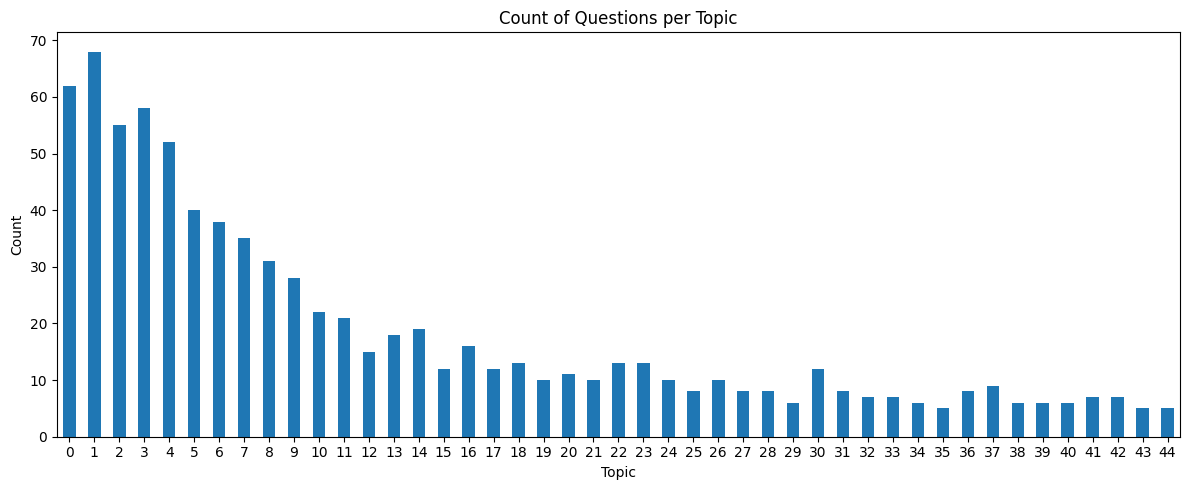

In [15]:
import matplotlib.pyplot as plt

topic_counts = df_sentences["Topics"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
topic_counts.plot(kind="bar")
plt.title("Count of Questions per Topic")
plt.xlabel("Topic")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [16]:
# Build one-word labels from highest c-TF-IDF keyword per topic
topic_info = topic_model.get_topic_info()

one_word_labels = {}
used_labels = set()

for topic_id in topic_info["Topic"]:
    if topic_id == -1:
        continue  # outlier topic

    # BERTopic returns (word, score) sorted by score descending
    word_scores = topic_model.get_topic(topic_id)

    # Pick the highest-score unigram not in blocked list; fallback to first entry
    if topic_id == 6:
        label = word_scores[5][0]
    elif topic_id == 28:
        label = word_scores[8][0]
    else:
        label = word_scores[0][0]

    # Keep labels unique if duplicate top words appear across topics
    base = label
    n = 2
    while label in used_labels:
        label = f"{base}_{n}"
        n += 1

    used_labels.add(label)
    one_word_labels[topic_id] = label

# Apply labels to BERTopic + dataframe
topic_model.set_topic_labels(one_word_labels)
df_sentences["Topic_Label"] = df_sentences["Topics"].map(one_word_labels).fillna("outlier")

# Preview
label_table = (
    df_sentences[["Topics", "Topic_Label"]]
    .drop_duplicates()
    .sort_values("Topics")
)
label_table

,Topics,Topic_Label
49,0,relationship
2,1,happiness
29,2,treatment
111,3,forgive
7,4,money
16,5,gambling
10,6,process
12,7,meaning
230,8,death
4,9,faith


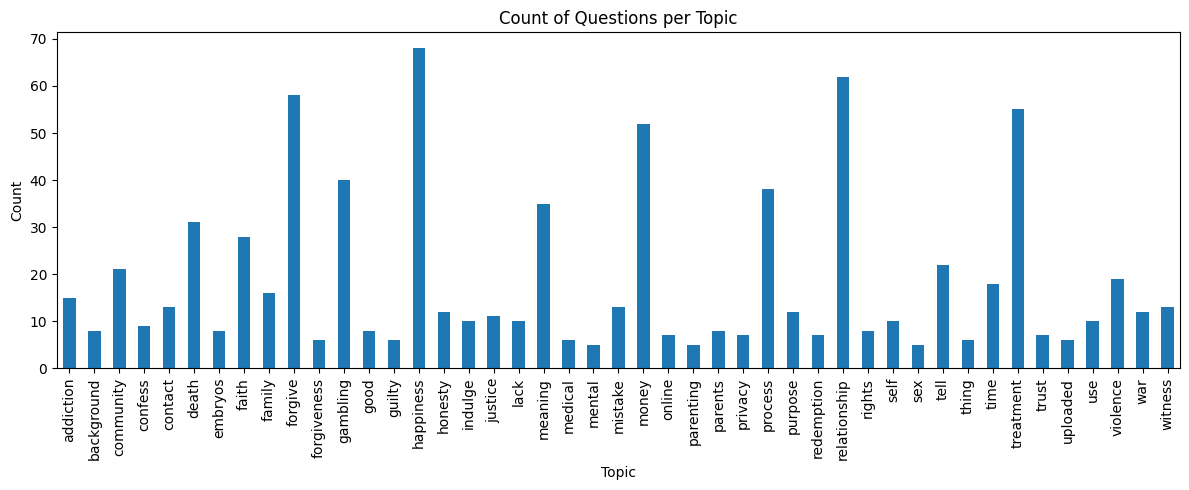

In [17]:
label_counts = df_sentences["Topic_Label"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
label_counts.plot(kind="bar")
plt.title("Count of Questions per Topic")
plt.xlabel("Topic")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [18]:
# Keep only the fields you want to share
export_df = df_sentences[["Question", "Topics", "Topic_Label"]].copy()

# Save detailed rows
export_df.to_csv("sementic_clusters_pof_questions.csv", index=False, encoding="utf-8")

# Optional: save summary counts
summary_df = (
    export_df.groupby(["Topics", "Topic_Label"], as_index=False)
    .size()
    .rename(columns={"size": "Count"})
    .sort_values("Count", ascending=False)
)
summary_df.to_csv("topic_summary.csv", index=False, encoding="utf-8")

In [19]:
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Summary for chart
plot_df = (
    df_sentences.groupby(["Topics", "Topic_Label"], as_index=False)
    .size()
    .rename(columns={"size": "Count"})
    .sort_values("Count", ascending=False)
)

# Bar chart
bar = px.bar(
    plot_df.sort_values("Topics"),
    x="Topic_Label",
    y="Count",
    hover_data=["Topics"],
    title="Question Count by Topic Label"
)
bar.update_layout(xaxis_tickangle=-45)

# Optional table preview (top 100 rows for readability)
table_df = df_sentences[["Question", "Topics", "Topic_Label"]].head(100)

fig = make_subplots(
    rows=2, cols=1,
    vertical_spacing=0.12,
    row_heights=[0.55, 0.45],
    specs=[[{"type": "xy"}], [{"type": "table"}]],
    subplot_titles=("Topic Counts", "Sample Rows (Top 100)")
)

for tr in bar.data:
    fig.add_trace(tr, row=1, col=1)

fig.add_trace(
    go.Table(
        header=dict(values=list(table_df.columns)),
        cells=dict(values=[table_df[c] for c in table_df.columns])
    ),
    row=2, col=1
)

fig.update_layout(height=900, title="BERTopic Results Dashboard")
fig.write_html("topic_dashboard.html", include_plotlyjs="cdn")
fig.show()

In [20]:
import json
from html import escape

# 1) Build grouped data: Topic_Label -> list of questions
grouped = (
    df_sentences[["Topic_Label", "Question"]]
    .fillna({"Topic_Label": "outlier"})
    .groupby("Topic_Label")["Question"]
    .apply(list)
    .to_dict()
)

# Optional: sort categories by number of questions (largest first)
grouped = dict(sorted(grouped.items(), key=lambda kv: len(kv[1]), reverse=True))

# 2) Prepare chart data
labels = list(grouped.keys())
counts = [len(grouped[label]) for label in labels]

# 3) Build HTML blocks (no subcategories, only categories -> questions)
sections_html = []
for label, questions in grouped.items():
    q_items = "\n".join(f"<li>{escape(q)}</li>" for q in questions)
    section = f"""
    <details class="category">
      <summary>
        <span class="name">{escape(str(label))}</span>
        <span class="count">{len(questions)} questions</span>
      </summary>
      <ul>
        {q_items}
      </ul>
    </details>
    """
    sections_html.append(section)

sections_html = "\n".join(sections_html)

# 4) Full HTML page
html_text = f"""<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8" />
  <meta name="viewport" content="width=device-width, initial-scale=1.0" />
  <title>Topic Questions Dashboard</title>
  <script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
  <style>
    body {{
      margin: 0;
      font-family: "Segoe UI", Tahoma, sans-serif;
      background: #f5f7fb;
      color: #1f2937;
    }}
    .container {{
      max-width: 1100px;
      margin: 24px auto;
      background: #fff;
      border-radius: 12px;
      box-shadow: 0 8px 24px rgba(0,0,0,0.08);
      overflow: hidden;
    }}
    .header {{
      background: #1e3a8a;
      color: white;
      padding: 20px 24px;
    }}
    .header h1 {{
      margin: 0;
      font-size: 24px;
    }}
    .header p {{
      margin: 8px 0 0 0;
      opacity: 0.9;
    }}
    .content {{
      padding: 20px 24px;
    }}
    .category {{
      border: 1px solid #e5e7eb;
      border-radius: 10px;
      margin-bottom: 12px;
      background: #fafafa;
    }}
    summary {{
      cursor: pointer;
      list-style: none;
      display: flex;
      justify-content: space-between;
      align-items: center;
      padding: 14px 16px;
      font-weight: 600;
    }}
    summary::-webkit-details-marker {{
      display: none;
    }}
    .count {{
      font-size: 12px;
      color: #374151;
      background: #dbeafe;
      padding: 4px 8px;
      border-radius: 999px;
    }}
    ul {{
      margin: 0;
      padding: 0 24px 16px 40px;
    }}
    li {{
      margin: 6px 0;
      line-height: 1.45;
    }}
    .chart-wrap {{
      margin-top: 28px;
      border-top: 2px solid #e5e7eb;
      padding-top: 20px;
    }}
    .chart-title {{
      margin: 0 0 12px 0;
      font-size: 18px;
      font-weight: 700;
    }}
    .footer {{
      padding: 14px 24px 20px 24px;
      color: #6b7280;
      font-size: 12px;
    }}
  </style>
</head>
<body>
  <div class="container">
    <div class="header">
      <h1>Questions by Topic</h1>
      <p>Total Questions: {sum(counts)} | Total Topics: {len(labels)}</p>
    </div>

    <div class="content">
      {sections_html}

      <div class="chart-wrap">
        <h2 class="chart-title">Question Count by Topic</h2>
        <canvas id="topicChart" height="100"></canvas>
      </div>
    </div>

    <div class="footer">
      Generated from df_sentences (Question, Topics, Topic_Label)
    </div>
  </div>

  <script>
    const labels = {json.dumps(labels)};
    const counts = {json.dumps(counts)};

    const ctx = document.getElementById("topicChart");
    new Chart(ctx, {{
      type: "bar",
      data: {{
        labels: labels,
        datasets: [{{
          label: "Questions",
          data: counts
        }}]
      }},
      options: {{
        responsive: true,
        plugins: {{
          legend: {{ display: false }}
        }},
        scales: {{
          x: {{
            ticks: {{
              maxRotation: 70,
              minRotation: 45
            }}
          }},
          y: {{
            beginAtZero: true
          }}
        }}
      }}
    }});
  </script>
</body>
</html>
"""

# 5) Save file
output_file = "topic_questions_visualization.html"
with open(output_file, "w", encoding="utf-8") as f:
    f.write(html_text)

print(f"Saved: {output_file}")

Saved: topic_questions_visualization.html
